# Autism Spectrum Detection — Improved Training Pipeline

1. **Added augmentation** (rotation/shift/zoom/flip/brightness) to the training generator only — validation/test stay clean for an honest evaluation.
2. **Added `class_weight`** to handle any train-set imbalance instead of assuming it's balanced.
3. **Kept BatchNorm layers frozen during fine-tuning** even after unfreezing conv layers — unfreezing BN with small batches corrupts running statistics and typically *hurts* val accuracy.
4. **Stronger head**: `GlobalAveragePooling2D → BatchNorm → Dense(256, L2) → Dropout → Dense(1, sigmoid)` instead of a bare `Dense(512)`, to fight overfitting.
5. **Added `ModelCheckpoint` + `ReduceLROnPlateau`** so to keep the best epoch and decay the LR automatically instead of a single fixed fine-tune LR.
6. **Gradual, larger unfreeze with a lower LR floor**, and label smoothing on the loss.
7. **Real evaluation**: confusion matrix + classification report (precision/recall/F1 per class), not just accuracy — important since accuracy alone hides class imbalance problems.
8. Combined the two training-phase histories into one continuous accuracy/loss curve so you can see the fine-tune transition clearly.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/content/drive/MyDrive/DataSet ASD Research'):
    print(dirname)


/content/drive/MyDrive/DataSet ASD Research
/content/drive/MyDrive/DataSet ASD Research/Project Based
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/val
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/val/Non_Autistic
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/val/Autistic
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/test
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/test/Autistic
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/test/Non_Autistic
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial dataset of autistic children/train
/content/drive/MyDrive/DataSet ASD Research/Project Based/Facial data

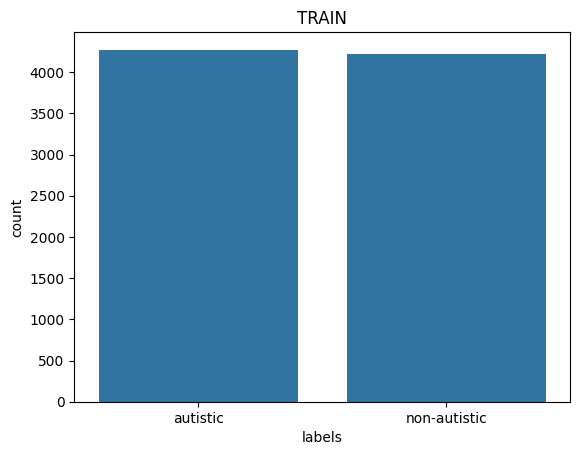

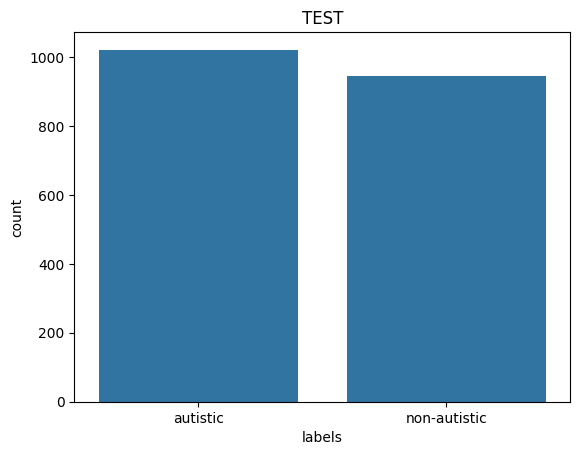

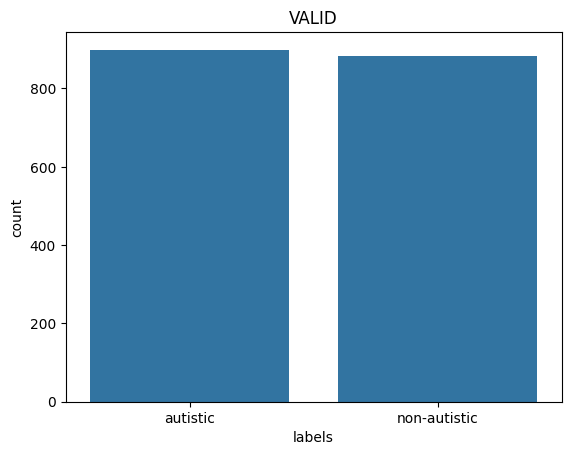

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/DataSet ASD Research/Project Based/Cleaned Dataset/cleaned_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/DataSet ASD Research/Project Based/Cleaned Dataset/cleaned_test.csv")
valid_df = pd.read_csv("/content/drive/MyDrive/DataSet ASD Research/Project Based/Cleaned Dataset/cleaned_valid.csv")

sns.countplot(x='labels', data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels', data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels', data=valid_df)
plt.title('VALID')
plt.show()


## Data generators — bug fixed

Only `preprocessing_function=preprocess_input` is used now (it already scales to `[-1, 1]`).
`rescale=1./255` has been **removed** everywhere — that was the double-normalization bug.

Augmentation is applied to the **training** generator only. Validation/test generators are left
clean (no augmentation, `shuffle=False`) so evaluation numbers are trustworthy and reproducible.

In [ ]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest",
)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42,
)

# No augmentation for validation/test - just the model's expected preprocessing
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

valid_gen = eval_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

test_gen = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)


Found 8496 validated image filenames belonging to 2 classes.
Found 1782 validated image filenames belonging to 2 classes.
Found 1966 validated image filenames belonging to 2 classes.
Class indices: {'autistic': 0, 'non-autistic': 1}


## Class weights

Computed straight from the training labels so the loss compensates for any imbalance
between `autistic` / `non_autistic` counts you saw in the countplot above.

In [ ]:
class_labels = np.array(sorted(train_gen.class_indices, key=train_gen.class_indices.get))
y_train_int = train_df['labels'].map(train_gen.class_indices).values

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int,
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(0.9943820224719101), 1: np.float64(1.0056818181818181)}


In [ ]:
base_model = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Head — stronger regularization

Added `BatchNormalization` after pooling and L2 weight decay on the dense layer, and dropped
the dense width from 512 -> 256 (less capacity to overfit a relatively small facial-image dataset).

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base_model.input, outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,335,777 (85.20 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [ ]:
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
)

checkpoint = ModelCheckpoint(
    "best_head_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)


In [ ]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    epochs=25,
)


Epoch 1/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 4207s 16s/step - accuracy: 0.7106 - loss: 0.8353 - val_accuracy: 0.7682 - val_loss: 0.5479 - learning_rate: 0.0010
Epoch 2/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.7640 - loss: 0.5837 - val_accuracy: 0.8148 - val_loss: 0.4904 - learning_rate: 0.0010
Epoch 3/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7932 - loss: 0.5253 - val_accuracy: 0.8277 - val_loss: 0.4901 - learning_rate: 0.0010
Epoch 4/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 264s 992ms/step - accuracy: 0.8100 - loss: 0.5069 - val_accuracy: 0.8401 - val_loss: 0.4603 - learning_rate: 0.0010
Epoch 5/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 265s 996ms/step - accuracy: 0.8144 - loss: 0.4954 - val_accuracy: 0.8373 - val_loss: 0.4591 - learning_rate: 0.0010
Epoch 6/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 266s 1000ms/step - accuracy: 0.8225 - loss: 0.4872 - val_accuracy: 0.8395 - val_loss: 0.4660 - learning_rate: 0.0010
Epoch 7/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.824

## Fine-tuning — BatchNorm stays frozen

Unfreezing the last ~150 layers of InceptionV3, but **BatchNormalization layers are explicitly
kept frozen** even inside that range. Fine-tuning BN with a small batch size makes its running
mean/variance estimates noisy and typically *hurts* validation accuracy rather than helping.

In [ ]:
UNFREEZE_FROM = -150  # how deep to unfreeze into InceptionV3

for layer in base_model.layers[UNFREEZE_FROM:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False   # keep BN frozen even while fine-tuning
    else:
        layer.trainable = True

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"Trainable base layers: {trainable_count} / {len(base_model.layers)}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

checkpoint_ft = ModelCheckpoint(
    "best_finetuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-8,
)

history_finetune = model.fit(
    train_gen,
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    epochs=25,
    callbacks=[early_stop, checkpoint_ft, reduce_lr_ft],
)


Trainable base layers: 106 / 311
Epoch 1/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.9038 - loss: 0.3765 - val_accuracy: 0.9371 - val_loss: 0.3406 - learning_rate: 1.0000e-05
Epoch 2/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9317 - loss: 0.3394 - val_accuracy: 0.9444 - val_loss: 0.3185 - learning_rate: 1.0000e-05
Epoch 3/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.9454 - loss: 0.3156 - val_accuracy: 0.9568 - val_loss: 0.3109 - learning_rate: 1.0000e-05
Epoch 4/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.9527 - loss: 0.3018 - val_accuracy: 0.9658 - val_loss: 0.2939 - learning_rate: 1.0000e-05
Epoch 5/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.9589 - loss: 0.2946 - val_accuracy: 0.9596 - val_loss: 0.2984 - learning_rate: 1.0000e-05
Epoch 6/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9637 - loss: 0.2850 - val_accuracy: 0.9635 - val_loss: 0.2852 - learning_rate: 1.0000e-05
Epoch 7/25
266/266 ━━━━━━

## Training curves (continuous across both phases)

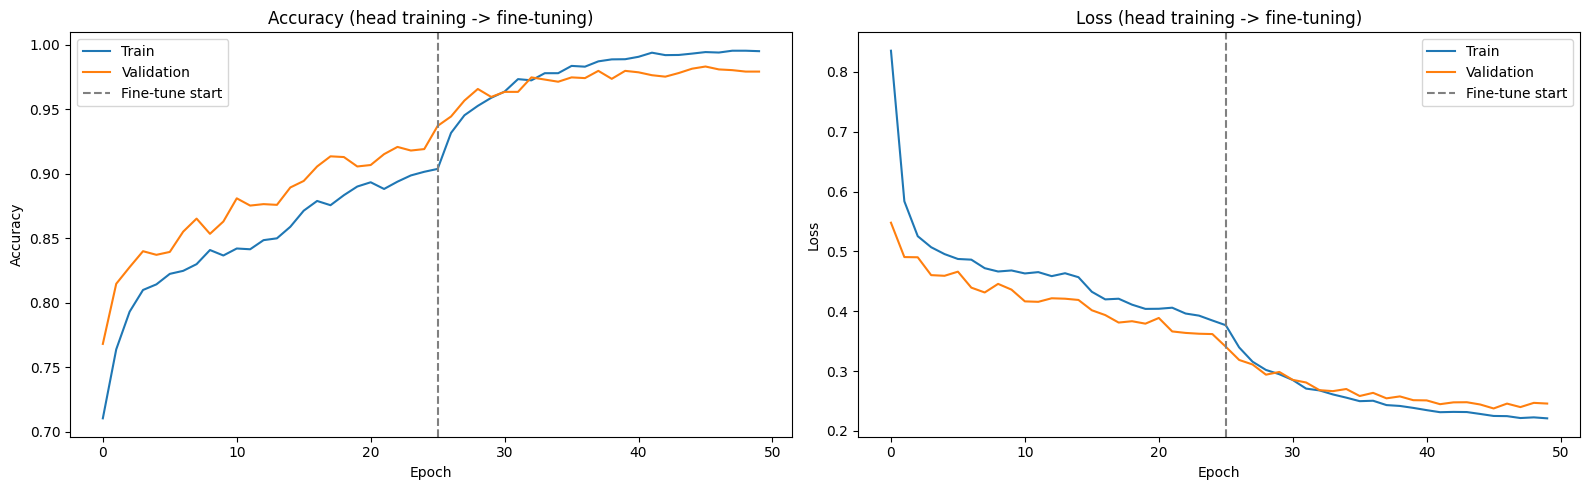

In [ ]:
def concat_hist(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = concat_hist(history, history_finetune, "accuracy")
val_acc = concat_hist(history, history_finetune, "val_accuracy")
loss = concat_hist(history, history_finetune, "loss")
val_loss = concat_hist(history, history_finetune, "val_loss")
switch_epoch = len(history.history.get("accuracy", []))

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

axs[0].plot(acc, label="Train")
axs[0].plot(val_acc, label="Validation")
axs[0].axvline(switch_epoch, color="gray", linestyle="--", label="Fine-tune start")
axs[0].set_title("Accuracy (head training -> fine-tuning)")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

axs[1].plot(loss, label="Train")
axs[1].plot(val_loss, label="Validation")
axs[1].axvline(switch_epoch, color="gray", linestyle="--", label="Fine-tune start")
axs[1].set_title("Loss (head training -> fine-tuning)")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()

plt.tight_layout()
plt.show()


## Evaluation — accuracy plus a real breakdown

`restore_best_weights=True` on `EarlyStopping` already loaded the best epoch's weights back into
`model`, so this evaluates the best checkpoint, not just whatever epoch training happened to stop on.

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob.ravel() > 0.5).astype(int)
y_true = test_gen.classes

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


54/62 ━━━━━━━━━━━━━━━━━━━━ 1:38 12s/step - accuracy: 0.9761 - loss: 0.2489

## Further ideas want more headroom

- **Try a different / larger backbone** (`EfficientNetB3`, `ConvNeXtTiny`) — InceptionV3 is older and often underperforms EfficientNet-family models on fine-grained facial classification at similar cost.
- **Test-time augmentation (TTA)**: average predictions over a few augmented copies of each test image.
- **K-fold cross-validation** on train+valid combined, since facial-image ASD datasets tend to be small and a single train/valid split can be noisy.
- **Face alignment/cropping preprocessing** (e.g., MTCNN face crop before feeding the network) so the model focuses on facial landmarks rather than background.
- **Two-stage LR schedule with cosine decay** instead of `ReduceLROnPlateau`, often gives smoother convergence during fine-tuning.
- Double-check for **data leakage**: make sure the same child/subject doesn't appear in both train and test (common issue in small medical image datasets) — this can inflate accuracy in a way that doesn't generalize.
